In [4]:
import xarray as xr
import shapely
import dask.array as da
import numpy as np
import geopandas as gpd
from pyproj import CRS, Transformer
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature


# CRSs
WGS84 = CRS('epsg:4326')  # WGS84 : (lon, lat)
ETRS89UTM = CRS('epsg:25834') # ETRS89 / UTM zone 34N : (x, y)

shpfile = '/projappl/project_2018610/data/DTO4OWE_polygons/Wind_farms_Bothnian_Sea.shp'
shpfile_coast = '/projappl/project_2018610/data/coastal/nemo_nordic_10-20m_polygons.shp'
poly = gpd.read_file(shpfile)
poly_coast = gpd.read_file(shpfile_coast)

poly = poly.to_crs(ETRS89UTM)
poly_coast = poly_coast.to_crs(ETRS89UTM)

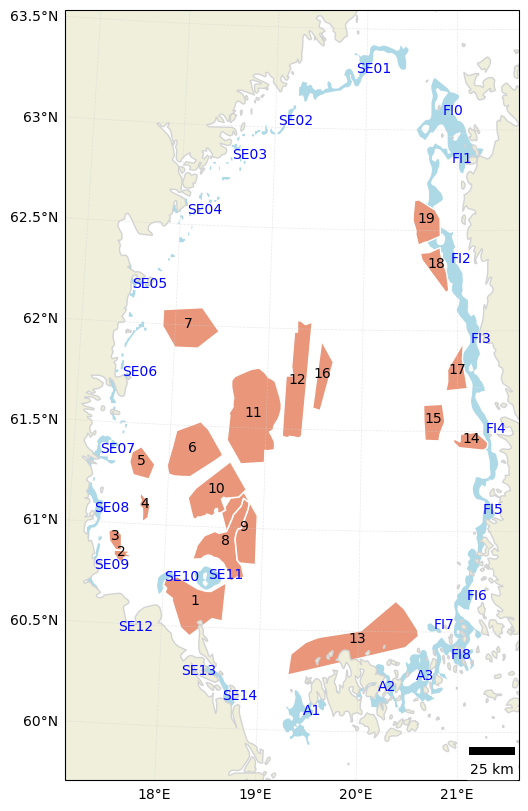

In [19]:
#Plot a map with OWFs and coastal areas
small = [2, 3, 4, 5, 9, 14, 15, 16, 17, 18, 19] # Smaller farms: one simulation for the whole summer
medium = [1, 6, 7, 8, 10, 12] # Medium farms : summer divided in two simulations

years = [2012, 2018]
        
utm_proj = ccrs.UTM(zone=34)

fig, ax = plt.subplots(
    figsize=(8, 10),
    subplot_kw={"projection": utm_proj}
)


# Plot the coastal areas
poly_coast.plot(edgecolor="none", facecolor="lightblue",ax=ax)
for _, row in poly_coast.iterrows():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(x, y, str(row["ID"]), color='blue', fontsize=10, ha="left")

#Plot the wind farm as polygons
poly.plot(edgecolor="white", facecolor="darksalmon",ax=ax) 
for _, row in poly.iterrows():
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(x, y, str(row["FarmID"]), color='black', fontsize=10, ha="center")


# Add land feature, overriding the default negative zorder so it shows
# above the background image.
ax.add_feature(cfeature.LAND, zorder=1, edgecolor='lightgrey')

# --- Lat/Lon gridlines  ---
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),   # gridlines defined in lat/lon
    draw_labels=True,
    linewidth=0.5,
    color='lightgray',
    alpha=0.5,
    linestyle='--'
)
gl.top_labels = False
gl.right_labels = False
gl.xformat = "DMS"  # or leave default decimal degrees
gl.yformat = "DMS"


scalebar = ScaleBar(1, location='lower right', units='m', length_fraction=0.1, rotation='horizontal-only')
ax.add_artist(scalebar)
# ax.set_title("Offshore wind farms and coastal areas")
plt.savefig('map_OWF_coast.png')

plt.show()